> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 9. Bias, Variance and Regularization

*Scope:* Why models fail in two opposite directions, how to tell which is happening, and the general principle that fixes one of them.

Models fail in two opposite directions, and the cures are opposite too. Applying the wrong one makes things
worse, so telling them apart is the diagnostic skill this chapter teaches.

Chapter 8 gave the measuring instruments. This chapter uses them to answer a single question — **is this
model too simple or too complex?** — and Chapters 12, 17 and 19 all reach back to the vocabulary defined
here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (KFold, StratifiedKFold, cross_validate, learning_curve,
                                     train_test_split, validation_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 110)
sns.set_theme(style="whitegrid")
print("ready")

ready


### 9.1 Underfitting and Overfitting

| | Underfitting | Overfitting |
|---|---|---|
| The model is | Too simple for the pattern | Too flexible for the amount of data |
| Training score | **Poor** | Excellent, often perfect |
| Validation score | Poor, and close to the training score | Much worse than training |
| Gap between them | Small | **Large** |
| Dominated by | **Bias** (9.2) | **Variance** (9.2) |
| Fix by | More capacity, better features, less regularization | Less capacity, more data, more regularization |

The two scores together are the diagnosis. Either one alone is uninformative — 8.1 showed why a training
score means nothing on its own, and a mediocre validation score is consistent with both failures.

The cleanest demonstration is polynomial regression, where capacity is a single integer.

In [2]:
def make_curve_data(n, noise=0.25, seed=0):
    """A smooth true function plus noise. The true relationship is a cubic."""
    gen = np.random.default_rng(seed)
    x = gen.uniform(-3, 3, n)
    y_true = 0.4 * x ** 3 - 1.2 * x + 2
    return x.reshape(-1, 1), y_true + gen.normal(0, noise * 3, n), y_true


X_c, y_c, _ = make_curve_data(60, seed=RANDOM_STATE)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.35, random_state=RANDOM_STATE)

for degree in (1, 3, 20):
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    model.fit(Xc_tr, yc_tr)
    tr = mean_squared_error(yc_tr, model.predict(Xc_tr))
    te = mean_squared_error(yc_te, model.predict(Xc_te))
    print(f"degree {degree:>2}   train MSE {tr:>8.3f}   test MSE {te:>10.3f}   gap {te - tr:>10.3f}")

degree  1   train MSE    2.772   test MSE      3.726   gap      0.954
degree  3   train MSE    0.272   test MSE      0.366   gap      0.094
degree 20   train MSE    0.162   test MSE      0.566   gap      0.404


Degree 1 is underfitting: both errors are large and similar — the model cannot represent a cubic, so more
data would not help. Degree 20 is overfitting: training error is near zero and test error is far worse.
Degree 3, the true degree, sits between them.

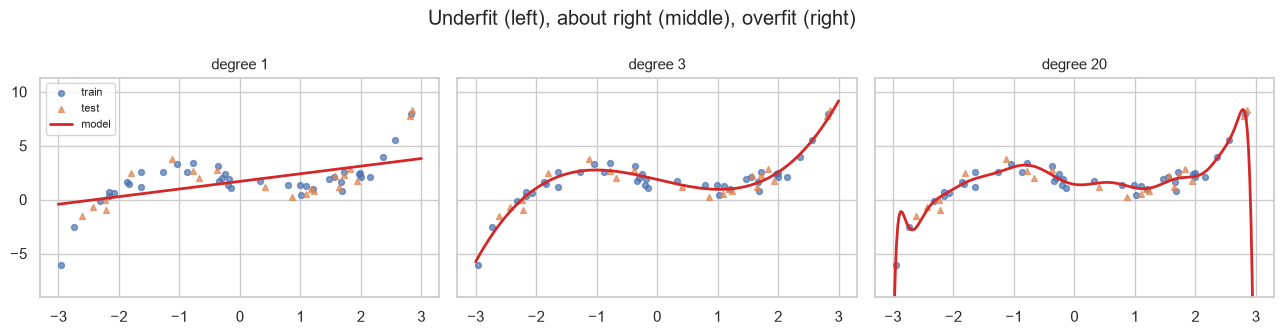

In [3]:
grid = np.linspace(-3, 3, 300).reshape(-1, 1)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)

for ax, degree in zip(axes, (1, 3, 20)):
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    model.fit(Xc_tr, yc_tr)
    ax.scatter(Xc_tr, yc_tr, s=18, alpha=0.7, label="train")
    ax.scatter(Xc_te, yc_te, s=18, alpha=0.7, marker="^", label="test")
    ax.plot(grid, model.predict(grid), color="tab:red", lw=2, label="model")
    ax.set_ylim(y_c.min() - 3, y_c.max() + 3)
    ax.set_title(f"degree {degree}", fontsize=11)

axes[0].legend(fontsize=8)
fig.suptitle("Underfit (left), about right (middle), overfit (right)")
fig.tight_layout()
plt.show()

**Common mistake — treating a large train/validation gap as the definition of overfitting.** The gap is a
symptom, not the thing itself. What matters is the **validation score**: a model with a large gap and the
best validation score available is the model to ship. Chapter 19's boosted trees routinely fit the training
set almost perfectly and still generalize best.

In [4]:
rows = []
for degree in (2, 3, 5, 9):
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=1.0))
    model.fit(Xc_tr, yc_tr)
    rows.append({
        "degree": degree,
        "train MSE": mean_squared_error(yc_tr, model.predict(Xc_tr)),
        "test MSE": mean_squared_error(yc_te, model.predict(Xc_te)),
    })
frame = pd.DataFrame(rows)
frame["gap"] = frame["test MSE"] - frame["train MSE"]
print(frame.round(3).to_string(index=False))
print("\nsmallest gap :", frame.loc[frame['gap'].idxmin(), 'degree'])
print("best test MSE:", frame.loc[frame['test MSE'].idxmin(), 'degree'], "  <- the one to choose")

 degree  train MSE  test MSE   gap
      2      2.700     4.208 1.508
      3      0.348     0.548 0.201
      5      0.271     0.497 0.226
      9      0.284     0.555 0.272

smallest gap : 3
best test MSE: 5   <- the one to choose


### 9.2 The Bias-Variance Decomposition

The two failure modes are not merely opposites in practice — they are two additive terms in the expected
error. For squared-error loss, the expected error at a point $x$, averaged over all training sets you might
have drawn, decomposes exactly:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2}_{\text{bias}^2} + \underbrace{\mathbb{E}\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^2\right]}_{\text{variance}} + \underbrace{\sigma^2}_{\text{irreducible}}$$

| Term | Is | Caused by | Reduced by |
|---|---|---|---|
| **Bias²** | How far the *average* model is from the truth | The model family being too restrictive | More capacity |
| **Variance** | How much the model moves when the training data changes | The model chasing the sample | More data, less capacity, regularization |
| **Irreducible** | Noise in $y$ itself | The world | **Nothing** |

The expectation is over *training sets*. That makes it directly simulatable: draw many training sets, fit a
model on each, and measure how the predictions scatter.

In [5]:
N_DATASETS = 200
N_TRAIN = 40
NOISE_SD = 1.2

x_eval = np.linspace(-3, 3, 100).reshape(-1, 1)
f_true = 0.4 * x_eval.ravel() ** 3 - 1.2 * x_eval.ravel() + 2


def simulate(degree, n_datasets=N_DATASETS):
    """Fit `degree` on many independent training sets; return all predictions at x_eval."""
    preds = np.empty((n_datasets, len(x_eval)))
    for i in range(n_datasets):
        gen = np.random.default_rng(1000 + i)
        x = gen.uniform(-3, 3, N_TRAIN).reshape(-1, 1)
        y = 0.4 * x.ravel() ** 3 - 1.2 * x.ravel() + 2 + gen.normal(0, NOISE_SD, N_TRAIN)
        model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
        preds[i] = model.fit(x, y).predict(x_eval)
    return preds


preds_1 = simulate(1)
print("predictions from 200 separate training sets:", preds_1.shape)

predictions from 200 separate training sets: (200, 100)


In [6]:
def decompose(preds):
    mean_pred = preds.mean(axis=0)
    bias_sq = np.mean((mean_pred - f_true) ** 2)
    variance = np.mean(preds.var(axis=0))
    return bias_sq, variance


rows = []
for degree in (1, 2, 3, 5, 8, 12):
    bias_sq, variance = decompose(simulate(degree))
    rows.append({
        "degree": degree,
        "bias^2": bias_sq,
        "variance": variance,
        "irreducible": NOISE_SD ** 2,
        "total": bias_sq + variance + NOISE_SD ** 2,
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))

 degree  bias^2  variance  irreducible   total
      1   2.838     0.259         1.44   4.537
      2   2.859     0.548         1.44   4.847
      3   0.001     0.187         1.44   1.628
      5   0.002     0.403         1.44   1.845
      8   0.019     2.337         1.44   3.796
     12   1.717   881.161         1.44 884.317


Bias² falls sharply from degree 1 to degree 3 — where the model family finally contains the truth — and is
essentially zero thereafter. Variance rises monotonically with degree, slowly at first and then sharply.
The total is minimized where their sum is smallest, which is **not** where either one alone is smallest.

The irreducible column never moves. It is the noise added when the data was generated, and no model can
touch it: it is the floor on achievable error.

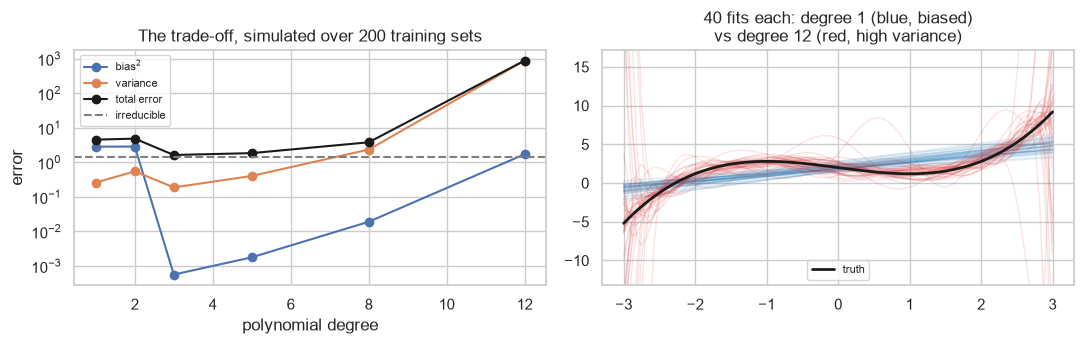

In [7]:
degrees = [1, 2, 3, 5, 8, 12]
curves = pd.DataFrame(rows).set_index("degree")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(curves.index, curves["bias^2"], "o-", label="bias$^2$")
axes[0].plot(curves.index, curves["variance"], "o-", label="variance")
axes[0].plot(curves.index, curves["total"], "o-", color="k", label="total error")
axes[0].axhline(NOISE_SD ** 2, color="tab:gray", ls="--", label="irreducible")
axes[0].set_xlabel("polynomial degree"); axes[0].set_ylabel("error")
axes[0].set_yscale("log")
axes[0].set_title("The trade-off, simulated over 200 training sets")
axes[0].legend(fontsize=8)

for degree, colour in ((1, "tab:blue"), (12, "tab:red")):
    p = simulate(degree, n_datasets=40)
    axes[1].plot(x_eval, p.T, color=colour, alpha=0.12, lw=1)
axes[1].plot(x_eval, f_true, "k-", lw=2, label="truth")
axes[1].set_ylim(f_true.min() - 8, f_true.max() + 8)
axes[1].set_title("40 fits each: degree 1 (blue, biased)\nvs degree 12 (red, high variance)")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

The right panel is the decomposition made visual. The blue fits sit almost on top of one another — low
variance — and all miss the curve the same way, which is bias. The red fits scatter wildly; each one is
wrong in a different direction, and their *average* is close to the truth. Low bias, high variance.

| Model family | Typically | Because |
|---|---|---|
| Linear regression, Naive Bayes | High bias, low variance | Strong assumptions, few parameters |
| Regularized linear models (Ch. 12) | Bias deliberately traded for variance | The penalty restricts the fit |
| Decision trees, unpruned (17.9) | Low bias, **very** high variance | They can fit anything, including noise |
| k-NN with small $k$ (14.6) | Low bias, high variance | Each prediction depends on few points |
| k-NN with large $k$ | Higher bias, low variance | Averaging over many points |
| Random forests (Ch. 18) | Low bias, **reduced** variance | Averaging many high-variance trees |
| Boosting (Ch. 19) | Bias reduced sequentially | Each model corrects its predecessor |

Chapter 18 exists entirely because of the fourth row: if a model family has low bias and high variance,
averaging many of them removes the variance and keeps the low bias.

### 9.3 Model Capacity and Complexity

**Capacity** is how rich a set of functions a model can express. It is not a single number, but every model
family has knobs that control it.

| Family | Increases capacity | Decreases capacity |
|---|---|---|
| Polynomial regression | Higher degree | Lower degree |
| Ridge / lasso (Ch. 12) | Smaller `alpha` | Larger `alpha` |
| Logistic regression (13.8) | Larger `C` | Smaller `C` |
| Decision tree (17.6) | Deeper, fewer `min_samples_leaf` | Shallower, more pruning |
| k-NN (14.6) | Smaller `k` | Larger `k` |
| SVM with RBF (16.6) | Larger `C`, larger `gamma` | Smaller `C`, smaller `gamma` |
| Random forest (18.6) | Deeper trees, more `max_features` | Shallower, fewer features per split |
| Boosting (19.6) | More estimators, higher learning rate | Fewer estimators, early stopping |

Two knobs are worth watching because they are backwards from intuition: in scikit-learn, `C` is an
**inverse** penalty (larger means *less* regularization), while `alpha` is a direct one.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

Xk, yk = make_classification(n_samples=300, n_features=20, n_informative=5,
                             random_state=RANDOM_STATE)

for C in (0.001, 0.1, 100.0):
    lr = LogisticRegression(C=C, max_iter=5000).fit(StandardScaler().fit_transform(Xk), yk)
    print(f"C = {C:>7}   mean |coefficient| = {np.abs(lr.coef_).mean():.4f}"
          f"   -> {'heavily constrained' if C < 0.01 else 'nearly unconstrained' if C > 10 else 'moderate'}")

for alpha in (0.01, 1.0, 100.0, 10000.0):
    r = Ridge(alpha=alpha).fit(StandardScaler().fit_transform(Xk), yk)
    print(f"alpha = {alpha:>9}   mean |coefficient| = {np.abs(r.coef_).mean():.5f}")

C =   0.001   mean |coefficient| = 0.0152   -> heavily constrained
C =     0.1   mean |coefficient| = 0.2433   -> moderate
C =   100.0   mean |coefficient| = 0.4349   -> nearly unconstrained
alpha =      0.01   mean |coefficient| = 0.05185
alpha =       1.0   mean |coefficient| = 0.05163
alpha =     100.0   mean |coefficient| = 0.03695
alpha =   10000.0   mean |coefficient| = 0.00161


Larger `C` gives larger coefficients (more capacity); larger `alpha` gives smaller ones (less capacity).
Getting the direction wrong is a real and common bug, because both parameters "regularize" and only one
of them increases with regularization strength.

Note also that `alpha = 0.01` and `alpha = 1.0` produce almost identical coefficients here. A penalty only
bites once $\lambda \Omega(\mathbf{w})$ is comparable in size to the loss term, so the useful range of
`alpha` depends on the scale of the data and the number of rows — which is why 12.7 searches it on a
logarithmic grid rather than a linear one.

**Capacity is relative to the amount of data.** A degree-12 polynomial is wildly overparameterized for 40
points and reasonable for 40,000. This is why "is this model too complex?" has no answer independent of $n$
— and why 9.4's learning curves are the right tool.

In [9]:
for n in (30, 100, 1000):
    X_n, y_n, _ = make_curve_data(n, seed=7)
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_n, y_n, test_size=0.3, random_state=RANDOM_STATE)
    model = make_pipeline(PolynomialFeatures(12), StandardScaler(), LinearRegression())
    model.fit(Xn_tr, yn_tr)
    tr = mean_squared_error(yn_tr, model.predict(Xn_tr))
    te = mean_squared_error(yn_te, model.predict(Xn_te))
    print(f"degree 12 on n={n:>5}   train MSE {tr:>7.3f}   test MSE {te:>9.3f}   ratio {te / tr:>7.1f}x")

degree 12 on n=   30   train MSE   0.127   test MSE  5383.792   ratio 42273.4x
degree 12 on n=  100   train MSE   0.370   test MSE     0.463   ratio     1.3x
degree 12 on n= 1000   train MSE   0.585   test MSE     0.574   ratio     1.0x


### 9.4 Learning Curves

A **learning curve** plots training and validation score against the *amount of training data*. It answers
a question no single score can: **would more data help?**

| Shape | Diagnosis | Do |
|---|---|---|
| Both scores poor, curves converged and flat | **Underfitting** (high bias) | More capacity or better features. **More data will not help** |
| Training high, validation much lower, still separating | **Overfitting** (high variance) | More data, more regularization, or less capacity |
| Both good and converged | Well fitted | Nothing; you are near the ceiling |
| Validation still climbing at the right edge | Data-limited | Collect more data — it will pay |

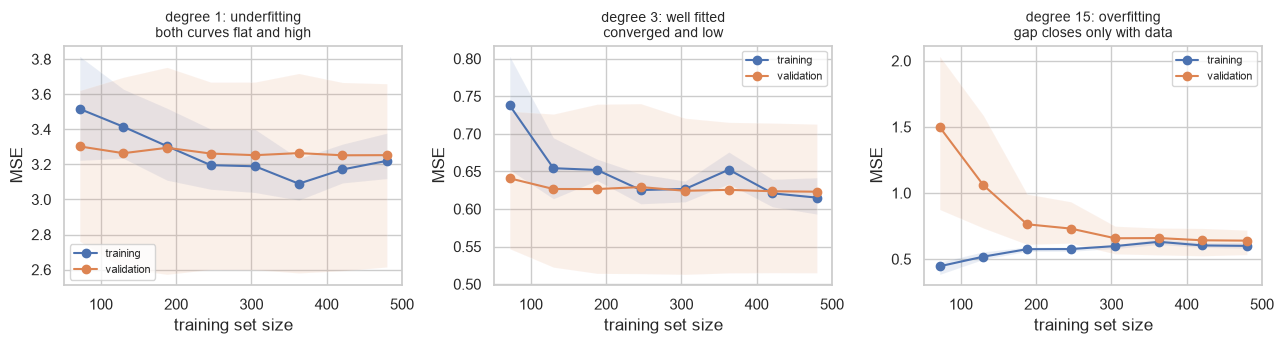

In [10]:
def plot_learning_curve(ax, estimator, X, y, title):
    sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        train_sizes=np.linspace(0.15, 1.0, 8), scoring="neg_mean_squared_error",
        random_state=RANDOM_STATE,
    )
    train_mse, val_mse = -train_scores.mean(axis=1), -val_scores.mean(axis=1)
    ax.plot(sizes, train_mse, "o-", label="training")
    ax.plot(sizes, val_mse, "o-", label="validation")
    ax.fill_between(sizes, -train_scores.min(axis=1), -train_scores.max(axis=1), alpha=0.12)
    ax.fill_between(sizes, -val_scores.min(axis=1), -val_scores.max(axis=1), alpha=0.12)
    ax.set_xlabel("training set size"); ax.set_ylabel("MSE")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    return sizes, train_mse, val_mse


X_big, y_big, _ = make_curve_data(600, seed=11)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
plot_learning_curve(axes[0], make_pipeline(PolynomialFeatures(1), LinearRegression()),
                    X_big, y_big, "degree 1: underfitting\nboth curves flat and high")
plot_learning_curve(axes[1], make_pipeline(PolynomialFeatures(3), LinearRegression()),
                    X_big, y_big, "degree 3: well fitted\nconverged and low")
plot_learning_curve(axes[2], make_pipeline(PolynomialFeatures(15), StandardScaler(), LinearRegression()),
                    X_big, y_big, "degree 15: overfitting\ngap closes only with data")
fig.tight_layout()
plt.show()

Read the three panels against the table. The left one has converged: the two curves meet at a high error
and stay there, so **collecting more data would change nothing** — this model cannot represent the
relationship. That is the most valuable thing a learning curve tells you, because it redirects effort from
data collection to feature engineering (Chapter 6) or a richer model.

The right panel shows the opposite: the gap is wide at small $n$ and narrows as data arrives, so more data
*is* the fix.

In [11]:
sizes, tr_mse, val_mse = learning_curve(
    make_pipeline(PolynomialFeatures(15), StandardScaler(), LinearRegression()),
    X_big, y_big, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.05, 1.0, 10), scoring="neg_mean_squared_error",
    random_state=RANDOM_STATE,
)
gap = (-val_mse.mean(axis=1)) - (-tr_mse.mean(axis=1))
print(pd.DataFrame({"n_train": sizes, "gap (val - train MSE)": gap.round(3)}).to_string(index=False))

 n_train  gap (val - train MSE)
      24               2765.030
      74                  1.018
     125                  0.535
     176                  0.285
     226                  0.149
     277                  0.061
     328                  0.045
     378                  0.031
     429                  0.046
     480                  0.040


### 9.5 Validation Curves

A **validation curve** holds the data fixed and varies a single hyperparameter. Where a learning curve asks
"would more data help?", a validation curve asks "**which setting is right?**" — and shows the
bias–variance trade-off directly as a U shape.

In [12]:
degrees = np.arange(1, 16)
train_scores, val_scores = validation_curve(
    make_pipeline(PolynomialFeatures(), StandardScaler(), LinearRegression()),
    X_c, y_c, param_name="polynomialfeatures__degree", param_range=degrees,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_squared_error",
)

train_mse, val_mse = -train_scores.mean(axis=1), -val_scores.mean(axis=1)
best_degree = degrees[val_mse.argmin()]

print(pd.DataFrame({"degree": degrees, "train MSE": train_mse.round(3),
                    "validation MSE": val_mse.round(3)}).to_string(index=False))
print(f"\nliteral minimum: degree {best_degree}   (the data was generated from a cubic)")

 degree  train MSE  validation MSE
      1      3.077           3.315
      2      3.050           3.509
      3      0.290           0.365
      4      0.288           0.385
      5      0.284           0.392
      6      0.271           0.556
      7      0.238           0.530
      8      0.224           0.469
      9      0.222           0.476
     10      0.212           0.551
     11      0.208           0.493
     12      0.206           0.500
     13      0.200           2.284
     14      0.195           0.364
     15      0.194           0.403

literal minimum: degree 14   (the data was generated from a cubic)


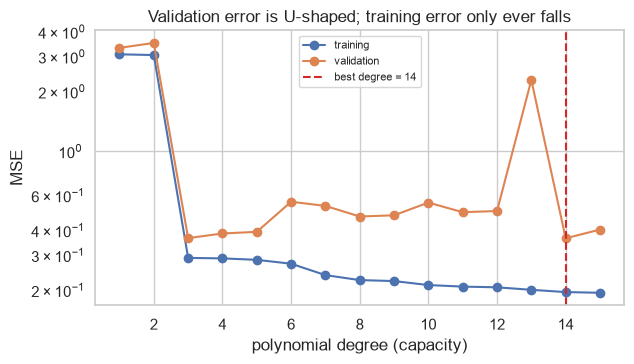

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(degrees, train_mse, "o-", label="training")
ax.plot(degrees, val_mse, "o-", label="validation")
ax.axvline(best_degree, color="tab:red", ls="--", label=f"best degree = {best_degree}")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree (capacity)"); ax.set_ylabel("MSE")
ax.set_title("Validation error is U-shaped; training error only ever falls")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The training curve descends more or less monotonically — more capacity fits the training data better, which
is 8.1's point again. The validation curve falls to a minimum around degree 3, rises through the middle
degrees, and then — awkwardly — dips again at the far end.

**And the literal minimum is degree 14, not 3.** The data was generated from a cubic, so 14 is the wrong
answer. This is not a flaw in the method; it is what a noisy curve looks like, and taking its `argmin`
uncritically is how a reasonable procedure produces an unreasonable model.

| Read | Region | Means |
|---|---|---|
| Both curves high | Left of the minimum | Underfitting |
| Validation rising, training still falling | Right of the minimum | Overfitting |
| Validation flat over a wide range | Anywhere | The hyperparameter does not matter much — pick the simpler end |

**Common mistake — taking the argmin of a validation curve.** The minimum of a noisy curve is itself
noisy. The standard remedy is the **one-standard-error rule**: among all settings whose score is within one
standard error of the best, choose the **simplest**.

In [14]:
val_se = (-val_scores).std(axis=1) / np.sqrt(val_scores.shape[1])
best_idx = val_mse.argmin()
threshold = val_mse[best_idx] + val_se[best_idx]
within = degrees[val_mse <= threshold]

print(f"literal minimum: degree {best_degree}, validation MSE "
      f"{val_mse[best_idx]:.3f} +/- {val_se[best_idx]:.3f} (s.e.)")
print(f"degrees within one standard error: {[int(d) for d in within]}")
print(f"simplest such degree: {int(within.min())}   <- the defensible choice, and the true degree")

literal minimum: degree 14, validation MSE 0.364 +/- 0.054 (s.e.)
degrees within one standard error: [3, 4, 5, 14, 15]
simplest such degree: 3   <- the defensible choice, and the true degree


Degree 3 is within one standard error of degree 14 and is vastly simpler, so the rule selects it — and it
happens to be the degree the data was generated from. The rule is not magic; it encodes a preference for
simplicity whenever the evidence cannot distinguish between options, which is exactly the situation
8.8.2 described.

`GridSearchCV` exposes this through its `refit` parameter, which accepts a callable that picks the index to
refit on — allowing a one-standard-error rule instead of `argmax` (23.5).

### 9.6 Regularization as a General Principle

**Regularization** is any modification that reduces variance at the cost of some bias. For a model fitted by
minimizing a loss, the standard form adds a penalty on the size of the parameters:

$$J(\mathbf{w}) = \underbrace{\text{Loss}(\mathbf{w})}_{\text{fit the data}} + \underbrace{\lambda \cdot \Omega(\mathbf{w})}_{\text{stay small}}$$

$\lambda$ controls the trade. At $\lambda = 0$ the penalty vanishes and the model is unconstrained; as
$\lambda \to \infty$ every coefficient is driven to zero and the model predicts a constant.

| Penalty $\Omega(\mathbf{w})$ | Name | Effect | Chapter |
|---|---|---|---|
| $\sum w_j^2$ | L2 / ridge | Shrinks all coefficients smoothly | 12.2 |
| $\sum \lvert w_j \rvert$ | L1 / lasso | Shrinks, and sets some to **exactly zero** | 12.3 |
| Both | Elastic net | Shrinks and selects | 12.5 |

The names are 2.3's norms, applied to the coefficient vector rather than to data.

In [15]:
X_reg, y_reg, _ = make_curve_data(35, noise=0.4, seed=3)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.35,
                                              random_state=RANDOM_STATE)

print(f"{'alpha':>10}{'train MSE':>12}{'test MSE':>14}{'max |coef|':>14}")
for alpha in (0.0, 1e-6, 0.001, 0.1, 10.0, 1000.0):
    model = make_pipeline(PolynomialFeatures(15), StandardScaler(),
                          Ridge(alpha=alpha) if alpha else LinearRegression())
    model.fit(Xr_tr, yr_tr)
    coefs = model[-1].coef_
    label = "0 (none)" if alpha == 0 else f"{alpha:g}"
    print(f"{label:>10}{mean_squared_error(yr_tr, model.predict(Xr_tr)):>12.3f}"
          f"{mean_squared_error(yr_te, model.predict(Xr_te)):>14.4g}{np.abs(coefs).max():>14.4g}")

     alpha   train MSE      test MSE    max |coef|
  0 (none)       0.858     5.836e+07          9458
     1e-06       0.922          7155         275.1
     0.001       1.048          2715         17.24
       0.1       1.162         105.1         1.803
        10       1.453          16.3        0.4015
      1000       3.932         14.49       0.03527


Read the last column alongside the first two. With no penalty, a degree-15 polynomial produces enormous
coefficients that cancel each other to pass through every training point — the same non-identifiability
pathology as 2.9's duplicated column. Raising `alpha` shrinks them, training error rises, and test error
falls until the penalty starts destroying real signal.

**Regularization is not only about penalties.** Anything that restricts what a model can express does the
same job:

| Mechanism | Family | Section |
|---|---|---|
| L1 / L2 penalty | Linear models, SVM, boosting | Ch. 12 |
| Max depth, min samples per leaf, pruning | Trees | 17.6 |
| Averaging many models | Ensembles | 18.1 |
| Random feature subsets per split | Random forests | 18.6 |
| Early stopping | Iterative learners | 9.7 |
| Fewer features | Everything | Ch. 7 |
| More data | Everything | 9.4 |

The last row is worth stating plainly: **more data is a form of regularization**, and usually the best one,
because it reduces variance without adding bias.

In [16]:
for n in (30, 120, 600):
    X_n, y_n, _ = make_curve_data(n, noise=0.4, seed=5)
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_n, y_n, test_size=0.3, random_state=RANDOM_STATE)
    unpenalized = make_pipeline(PolynomialFeatures(15), StandardScaler(), LinearRegression())
    unpenalized.fit(Xn_tr, yn_tr)
    print(f"degree 15, no penalty, n={n:>4}   test MSE "
          f"{mean_squared_error(yn_te, unpenalized.predict(Xn_te)):>10.3f}")

degree 15, no penalty, n=  30   test MSE   3783.045
degree 15, no penalty, n= 120   test MSE      2.068
degree 15, no penalty, n= 600   test MSE      1.204


### 9.7 Early Stopping

For a model fitted iteratively — gradient descent (Chapter 10), gradient boosting (19.6) — capacity grows
with each iteration. **Early stopping** halts training when validation performance stops improving, which
regularizes without changing the model at all.

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

Xe, ye, _ = make_curve_data(300, noise=0.5, seed=13)
Xe_tr, Xe_val, ye_tr, ye_val = train_test_split(Xe, ye, test_size=0.35, random_state=RANDOM_STATE)

booster = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=3,
                                    random_state=RANDOM_STATE).fit(Xe_tr, ye_tr)

train_path = np.array([mean_squared_error(ye_tr, p) for p in booster.staged_predict(Xe_tr)])
val_path = np.array([mean_squared_error(ye_val, p) for p in booster.staged_predict(Xe_val)])
best_iter = val_path.argmin() + 1

print(f"iterations run           : {len(val_path)}")
print(f"best validation iteration: {best_iter}")
print(f"validation MSE there     : {val_path.min():.4f}")
print(f"validation MSE at the end: {val_path[-1]:.4f}")
print(f"training MSE at the end  : {train_path[-1]:.4f}   <- still improving, and irrelevant")

iterations run           : 500
best validation iteration: 25
validation MSE there     : 2.4299
validation MSE at the end: 3.7514
training MSE at the end  : 0.0467   <- still improving, and irrelevant


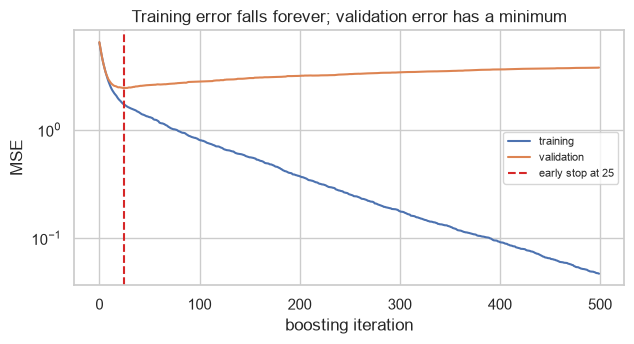

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(train_path, label="training")
ax.plot(val_path, label="validation")
ax.axvline(best_iter, color="tab:red", ls="--", label=f"early stop at {best_iter}")
ax.set_xlabel("boosting iteration"); ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_title("Training error falls forever; validation error has a minimum")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

scikit-learn implements this directly with `n_iter_no_change`, which carves out its own internal validation
fraction and stops when improvement stalls.

In [19]:
auto_stop = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.1, max_depth=3,
    validation_fraction=0.2, n_iter_no_change=15, tol=1e-4,
    random_state=RANDOM_STATE,
).fit(Xe_tr, ye_tr)

print(f"n_estimators requested : 500")
print(f"trees actually built   : {auto_stop.n_estimators_}")
print(f"validation MSE         : {mean_squared_error(ye_val, auto_stop.predict(Xe_val)):.4f}")
print(f"vs the full 500-tree model: {mean_squared_error(ye_val, booster.predict(Xe_val)):.4f}")

n_estimators requested : 500
trees actually built   : 49
validation MSE         : 2.6179
vs the full 500-tree model: 3.7514


**Common mistake — early stopping on the test set.** The stopping iteration is a hyperparameter chosen from
data (8.2). Choosing it on the test set makes the reported score optimistic. Use a dedicated validation
split, `validation_fraction`, or cross-validation.

### 9.8 The No-Free-Lunch Theorem

The no-free-lunch theorem states that, **averaged over all possible problems**, every learning algorithm
performs identically. No algorithm is universally best; superior performance on one class of problems is
paid for by inferior performance on another.

What follows from it, and what does not:

| Follows | Does not follow |
|---|---|
| There is no "best algorithm" to always reach for | All algorithms are equally good on *your* problem |
| Model choice must be justified empirically | Benchmarks are useless |
| An algorithm's assumptions are what make it work | Assumptions are a weakness |
| You must actually compare candidates (8.8) | Comparison is hopeless |

The reason it does not lead to paralysis is that real problems are not drawn uniformly from all possible
problems. Real data has structure — smoothness, locality, sparsity — and algorithms that assume that
structure do well on it. The theorem says the assumptions are doing the work, which is true and useful.

The practical version is easy to demonstrate: pick three datasets with different structure and watch the
ranking of the same three models change completely.

In [20]:
from sklearn.datasets import make_circles, make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

problems = {
    "linear, 50 features": make_classification(n_samples=300, n_features=50, n_informative=6,
                                               n_redundant=0, class_sep=1.2,
                                               random_state=RANDOM_STATE),
    "concentric circles": make_circles(n_samples=400, noise=0.12, factor=0.4,
                                       random_state=RANDOM_STATE),
    "interleaving moons": make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE),
}
learners = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "k-NN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "naive bayes": GaussianNB(),
}

table = {}
for pname, (Xp, yp) in problems.items():
    table[pname] = {
        lname: cross_val_score(l, Xp, yp, cv=StratifiedKFold(5, shuffle=True,
                                                             random_state=RANDOM_STATE)).mean()
        for lname, l in learners.items()
    }
scoreboard = pd.DataFrame(table).round(3)
print(scoreboard)
print("\nbest learner per problem:")
print(scoreboard.idxmax().to_string())
print("\nworst learner per problem:")
print(scoreboard.idxmin().to_string())

             linear, 50 features  concentric circles  interleaving moons
logistic                   0.867               0.452               0.840
k-NN (k=5)                 0.683               0.995               0.925
naive bayes                0.867               0.982               0.840

best learner per problem:
linear, 50 features      logistic
concentric circles     k-NN (k=5)
interleaving moons     k-NN (k=5)

worst learner per problem:
linear, 50 features    k-NN (k=5)
concentric circles       logistic
interleaving moons       logistic


The ranking **completely inverts** between the first two columns:

| | linear, 50 features | concentric circles |
|---|---|---|
| logistic | 0.867 — **best** | 0.453 — **worse than chance** |
| k-NN | 0.683 — **worst** | 0.995 — **best** |

Each model's failure is its own assumption applied where it does not hold. Logistic regression assumes a
linear boundary, which is ideal in 50 sparse dimensions and impossible on concentric circles (6.1's XOR
argument again). k-NN assumes nearby points share labels, which is perfect on the circles and collapses in
50 dimensions where nothing is near anything (7.1's distance-contrast result).

Neither model is better. Each is better *somewhere*, and the assumption that helps in one place is the
same assumption that fails in the other. That is the no-free-lunch theorem in a table.

**The practical rule this licenses:** always try several model families before tuning one. A cheap
comparison across three or four families costs minutes and is far more likely to help than hours spent
tuning the wrong one (23.8).

### 9.9 In Practice

#### 9.9.1 Where this shows up: diagnosing a disappointing model

The most common real use of this chapter is not a plot — it is a decision about **what to do next** when a
model underperforms. The wrong diagnosis wastes weeks: collecting more data for a high-bias model changes
nothing, and adding features to a high-variance model makes it worse.

The scenario: a churn model reaches 0.79 validation AUC and someone asks whether to buy more data.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


data = prepare(pd.read_csv("data/customers.csv"))
NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]
CATEGORICAL = ["gender", "city", "plan"]
X_ch = data[NUMERIC + CATEGORICAL]
y_ch = data["churned"]

encoder = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), CATEGORICAL),
])

cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("rows:", len(X_ch), " churn rate:", round(y_ch.mean(), 3))

rows: 1000  churn rate: 0.141


**Step 1 — measure the gap.** Train and validation scores together, from one `cross_validate` call (8.3.2).

In [22]:
candidates = {
    "logistic (C=1)": make_pipeline(encoder, LogisticRegression(max_iter=5000)),
    "logistic (C=0.01)": make_pipeline(encoder, LogisticRegression(C=0.01, max_iter=5000)),
    "forest (unlimited depth)": make_pipeline(encoder, RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE)),
    "forest (max_depth=4)": make_pipeline(encoder, RandomForestClassifier(
        n_estimators=200, max_depth=4, random_state=RANDOM_STATE)),
}

rows = []
for name, model in candidates.items():
    res = cross_validate(model, X_ch, y_ch, cv=cv5, scoring="roc_auc", return_train_score=True)
    rows.append({"model": name,
                 "train AUC": res["train_score"].mean(),
                 "val AUC": res["test_score"].mean(),
                 "gap": res["train_score"].mean() - res["test_score"].mean()})
print(pd.DataFrame(rows).round(4).to_string(index=False))

                   model  train AUC  val AUC    gap
          logistic (C=1)     0.8309   0.8049 0.0260
       logistic (C=0.01)     0.8251   0.8153 0.0098
forest (unlimited depth)     1.0000   0.7602 0.2398
    forest (max_depth=4)     0.8910   0.7861 0.1049


The diagnosis is in the `gap` column. The unlimited forest trains to a **perfect 1.0000 AUC** and validates
at 0.7602 — a gap of 0.24, textbook high variance. Both logistic regressions have gaps of about 0.01 and
validate *higher* than either forest, at around 0.815.

That is already an informative result: the best model here is the most constrained one, and the flexible
one is the worst. But the gap alone does not say what to do next, so ask the learning curve.

**Step 2 — ask the learning curve whether more data would help.**

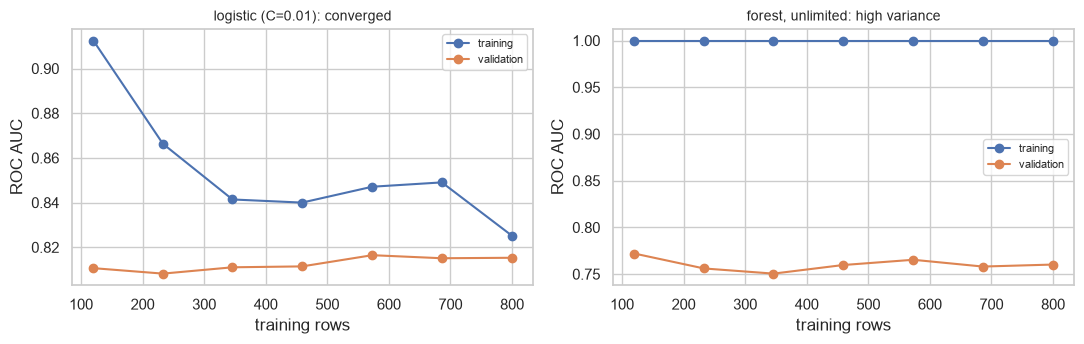

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for ax, (name, model) in zip(axes, [("logistic (C=0.01): converged", candidates["logistic (C=0.01)"]),
                                    ("forest, unlimited: high variance", candidates["forest (unlimited depth)"])]):
    sizes, tr, va = learning_curve(model, X_ch, y_ch, cv=cv5, scoring="roc_auc",
                                   train_sizes=np.linspace(0.15, 1.0, 7),
                                   random_state=RANDOM_STATE)
    ax.plot(sizes, tr.mean(axis=1), "o-", label="training")
    ax.plot(sizes, va.mean(axis=1), "o-", label="validation")
    ax.set_xlabel("training rows"); ax.set_ylabel("ROC AUC")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [24]:
for name in ("logistic (C=0.01)", "forest (unlimited depth)"):
    sizes, tr, va = learning_curve(candidates[name], X_ch, y_ch, cv=cv5, scoring="roc_auc",
                                   train_sizes=np.linspace(0.15, 1.0, 7), random_state=RANDOM_STATE)
    val_mean = va.mean(axis=1)
    improvement = val_mean[-1] - val_mean[-3]
    print(f"{name:<26} validation AUC over the last 3 sizes: "
          f"{val_mean[-3]:.4f} -> {val_mean[-1]:.4f}  ({improvement:+.4f})")

logistic (C=0.01)          validation AUC over the last 3 sizes: 0.8164 -> 0.8153  (-0.0012)


forest (unlimited depth)   validation AUC over the last 3 sizes: 0.7653 -> 0.7602  (-0.0051)


Both curves are flat by the full training size, and the numeric check confirms it: the validation score
moves by less than 0.006 over the last three training sizes, and in both cases it moves *down*. **Neither
model is data-limited.** More rows of the same kind would change nothing.

**Step 3 — act on the diagnosis.** The forest is high-variance, so constrain it:

In [25]:
forest_treatments = {
    "baseline: unlimited depth": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "max_depth=5": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=RANDOM_STATE),
    "min_samples_leaf=20": RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                                                  random_state=RANDOM_STATE),
    "max_depth=4, min_samples_leaf=20": RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=20, random_state=RANDOM_STATE),
}

for name, model in forest_treatments.items():
    res = cross_validate(make_pipeline(encoder, model), X_ch, y_ch, cv=cv5,
                         scoring="roc_auc", return_train_score=True)
    print(f"{name:<34} train {res['train_score'].mean():.4f}   val {res['test_score'].mean():.4f}"
          f"   gap {res['train_score'].mean() - res['test_score'].mean():.4f}")

baseline: unlimited depth          train 1.0000   val 0.7602   gap 0.2398


max_depth=5                        train 0.9247   val 0.7837   gap 0.1410


min_samples_leaf=20                train 0.8780   val 0.7881   gap 0.0899


max_depth=4, min_samples_leaf=20   train 0.8560   val 0.7915   gap 0.0645


Constraining works exactly as the theory predicts: training AUC falls, the gap shrinks from 0.24 to a few
hundredths, and **validation AUC rises**. That is bias traded for variance, profitably.

Now the logistic regression. Its gap is already tiny, so the textbook move would be to *add* capacity.
Sweep `C` and check.

In [26]:
print(f"{'C':>8}{'train AUC':>12}{'val AUC':>10}{'gap':>9}")
for C in (0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 10.0):
    res = cross_validate(make_pipeline(encoder, LogisticRegression(C=C, max_iter=5000)),
                         X_ch, y_ch, cv=cv5, scoring="roc_auc", return_train_score=True)
    tr_, va_ = res["train_score"].mean(), res["test_score"].mean()
    print(f"{C:>8}{tr_:>12.4f}{va_:>10.4f}{tr_ - va_:>9.4f}")

       C   train AUC   val AUC      gap


   0.003      0.8220    0.8144   0.0076


    0.01      0.8251    0.8153   0.0098


    0.03      0.8272    0.8151   0.0121


     0.1      0.8290    0.8117   0.0173


     0.3      0.8304    0.8077   0.0227


     1.0      0.8309    0.8049   0.0260


    10.0      0.8310    0.8031   0.0279


**Adding capacity makes it worse.** Validation AUC peaks at `C = 0.01` and declines monotonically to 0.803
at `C = 10`, while training AUC rises by only 0.009 across the entire range. The model is not
capacity-limited in either direction — it is **feature-limited**.

That is a third diagnosis, and it is the one this dataset actually has:

| Signature | Diagnosis |
|---|---|
| Large gap, validation improves when constrained | High variance |
| Small gap, validation improves when capacity is added | High bias |
| **Small gap, and neither more nor less capacity helps** | **Feature-limited or at the noise floor** |

The training score is the tell. A high-bias model cannot fit its *training* data either — degree 1 in 9.1
had a training MSE of 2.77 against 0.27 for degree 3. Here the training AUC is 0.831 at `C = 10`, barely
above the 0.822 at `C = 0.003`: the model is already extracting nearly everything these features contain,
and the remaining error is not something capacity can reach.

**The answer to the original question — should we buy more data?** No. The learning curves are flat, so
more rows of the same kind add nothing. The gap on the forest closes with regularization rather than data.
And the logistic regression's ceiling of about 0.82 does not move with capacity in either direction. The
binding constraint is what the seven numeric and three categorical columns can express — so the
highest-value next steps are **better features** (Chapter 6), **a different model family** (9.8), or
accepting that 0.82 is near this problem's irreducible limit (9.2).

#### 9.9.2 Which diagnosis, and what to do about it

| Symptom | Diagnosis | Do | Do **not** |
|---|---|---|---|
| Train and validation both poor, small gap | High bias | Add capacity, add features, reduce regularization | Collect more data (9.4) |
| Train excellent, validation much worse | High variance | Regularize, reduce capacity, collect more data | Add features |
| Small gap, and capacity changes nothing either way | Feature-limited or at the noise floor | Better features (Ch. 6), another family (9.8), or stop | Keep tuning (9.9.1) |
| Validation still rising with $n$ | Data-limited | Collect more data | Tune hyperparameters first |
| Validation curve flat across settings | The knob does not matter | Pick the simplest setting | Search it finely (9.5) |
| Validation score near the noise floor | At the irreducible limit (9.2) | Stop, or change the problem | Keep tuning |
| Several settings within one standard error | Not resolvable at this $n$ | Take the simplest | Report the maximum as best (8.8.2) |
| One model family fails badly | Wrong assumptions for this structure | Try other families (9.8) | Tune it harder |

#### 9.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Capacity tuned for the old data volume** | The model was right for 10k rows and is now underfitting 10M | 9.3 |
| **Regularization strength never revisited** | `alpha` was chosen once, two years ago | 9.6 |
| **Early stopping iteration frozen** | Retraining on more data stops at the old iteration count | 9.7 |
| **Overfitting to the validation set** | Hundreds of experiments against one split; the split is now training data | 8.2, 23.8 |
| **A model that was never compared** | The first family tried became the permanent choice | 9.8 |
| **Irreducible error mistaken for a model problem** | Months spent chasing error that is noise in the label | 9.2 |

The last row deserves the closing word. The irreducible term is real and often large: labels are noisy,
outcomes are partly random, and the same input genuinely produces different outputs. A team that does not
estimate that floor cannot tell "the model is bad" from "the problem is hard", and will keep spending on
the wrong one.

The cheapest estimate of the floor is the **disagreement rate between two human labellers**, or the
variation in the outcome for rows with identical features. If two experts disagree 12% of the time, a
model achieving 88% accuracy has reached the ceiling, and every further point of tuning is chasing noise.

In [27]:
# --- 9. Bias, Variance and Regularization — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.